# EDA of the PassivUK dataset

In [90]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter

## Load data

In [28]:
data_path = "data/PST_Data_20260216"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]
events_files = [f for f in glob(os.path.join(data_path, "*_Events_*_*.csv"))]

In [29]:
# First house:
house_id = temperature_files[0].split("/")[-1].split("_")[0]
house_df = pd.read_csv(temperature_files[0])

In [65]:
house_id

'30436'

# Preprocessing

In [43]:
# Convert time to datetime
house_df["Datetime"] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]

In [44]:
house_df.head()

,Time (UTC),Room temperature (Zone 1) (°C),Setpoint temperature (Zone 1) (°C),Space heating (0/1),Zone 1 heating (0/1),Flow temperature setpoint (°C),Hot water temperature (°C),Hot water usage setting,Hot water (0/1),Immersion call (0/1),Immersion status (0/1),Hot water setpoint (°C),Flow temperature (°C),Return temperature (°C),Defrost status (0/1),Tariff rate (p/kWh),External temperature (°C),Datetime
0,2025-10-01 00:00,21.7,22.0,1.0,1.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,27.0,25.0,0.0,NaN,19.0,2025-10-01 00:00:00
1,2025-10-01 00:05,21.7,22.0,0.0,0.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,25.0,0.0,NaN,19.0,2025-10-01 00:05:00
2,2025-10-01 00:10,21.7,22.0,0.0,0.0,48.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,25.0,0.0,NaN,19.0,2025-10-01 00:10:00
3,2025-10-01 00:15,21.7,22.0,1.0,1.0,55.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,24.0,0.0,NaN,19.0,2025-10-01 00:15:00
4,2025-10-01 00:20,21.7,22.0,1.0,1.0,55.0,50.0,NaN,0.0,1.0,0.0,20.0,25.0,24.0,0.0,NaN,19.0,2025-10-01 00:20:00


# Plot house time series

In [87]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [92]:
datapoints_in_week = (12*24)*7
datapoints_in_day = (12*24)

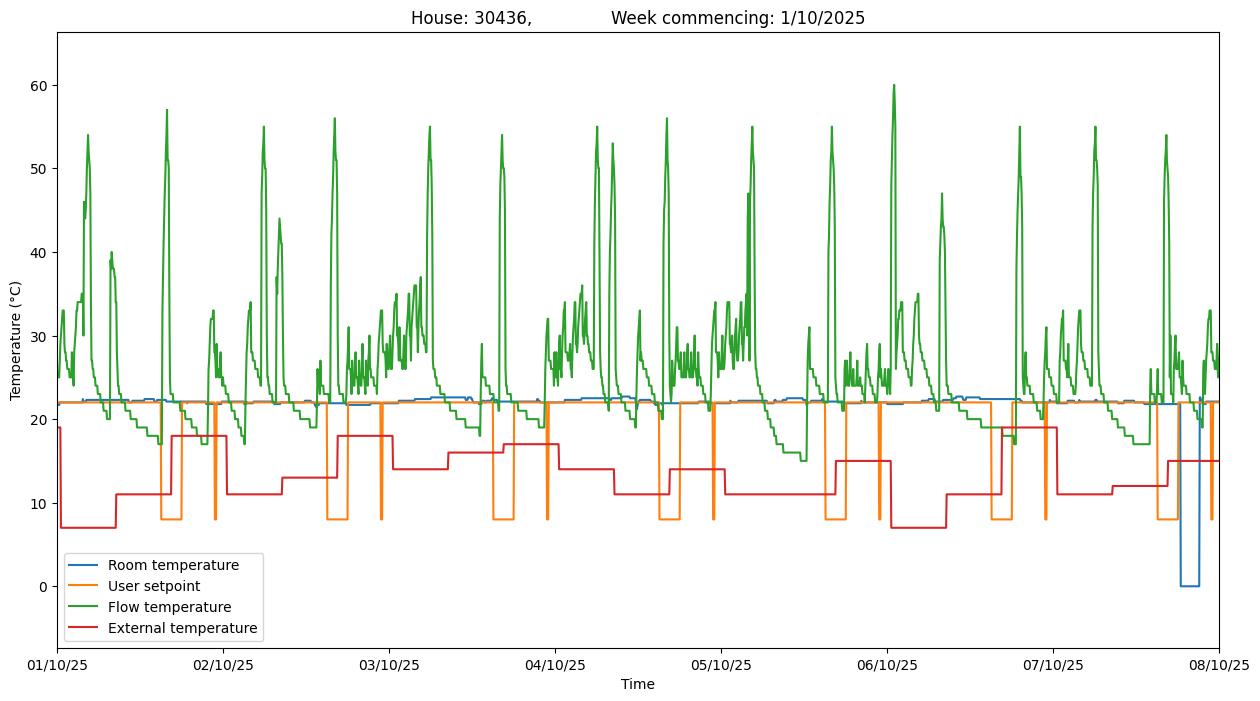

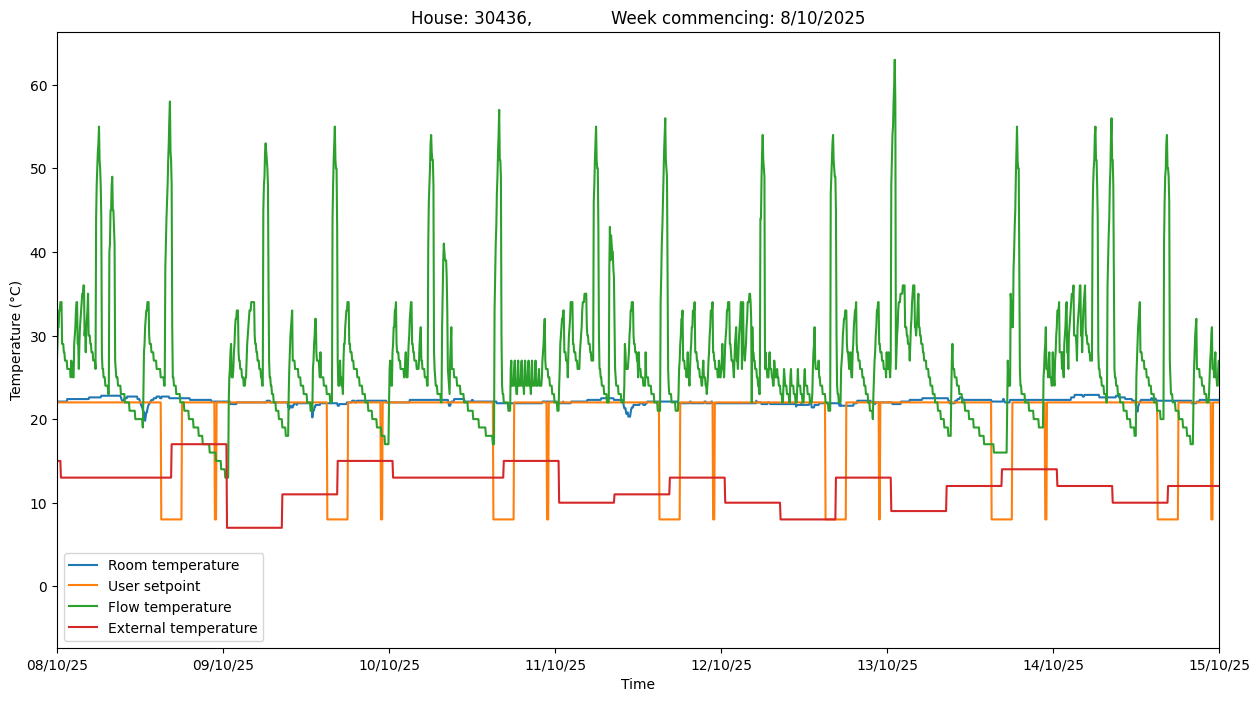

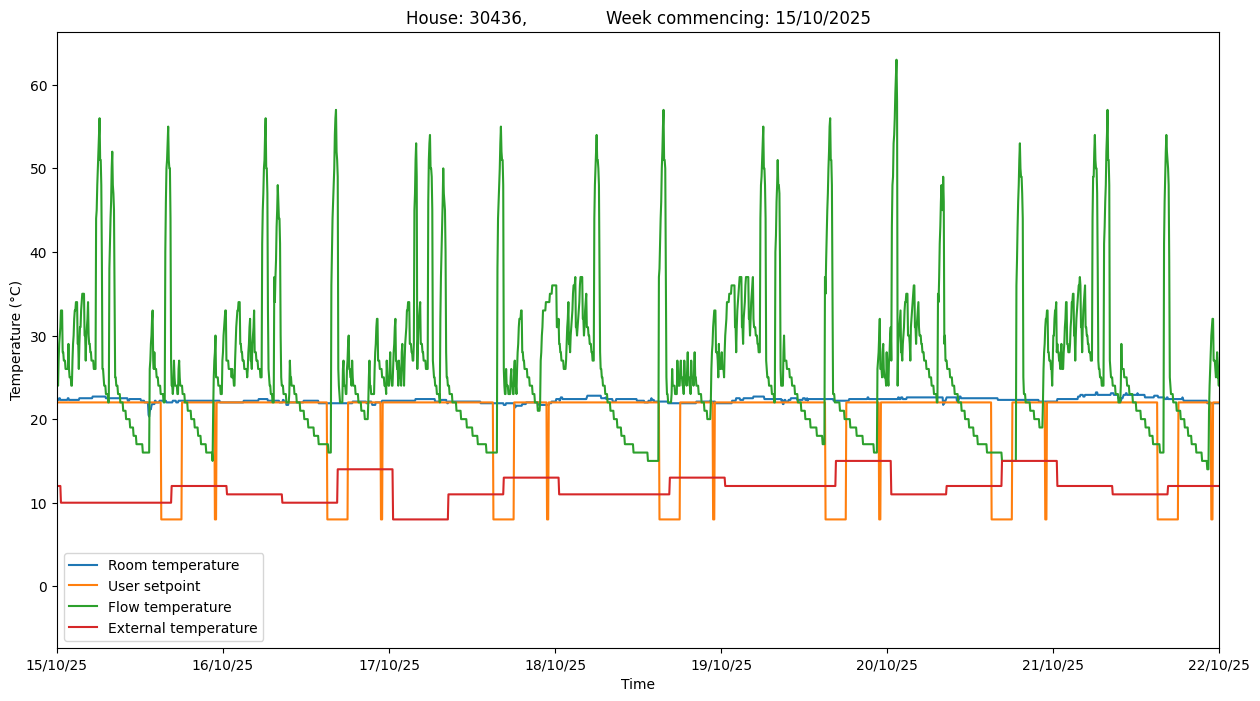

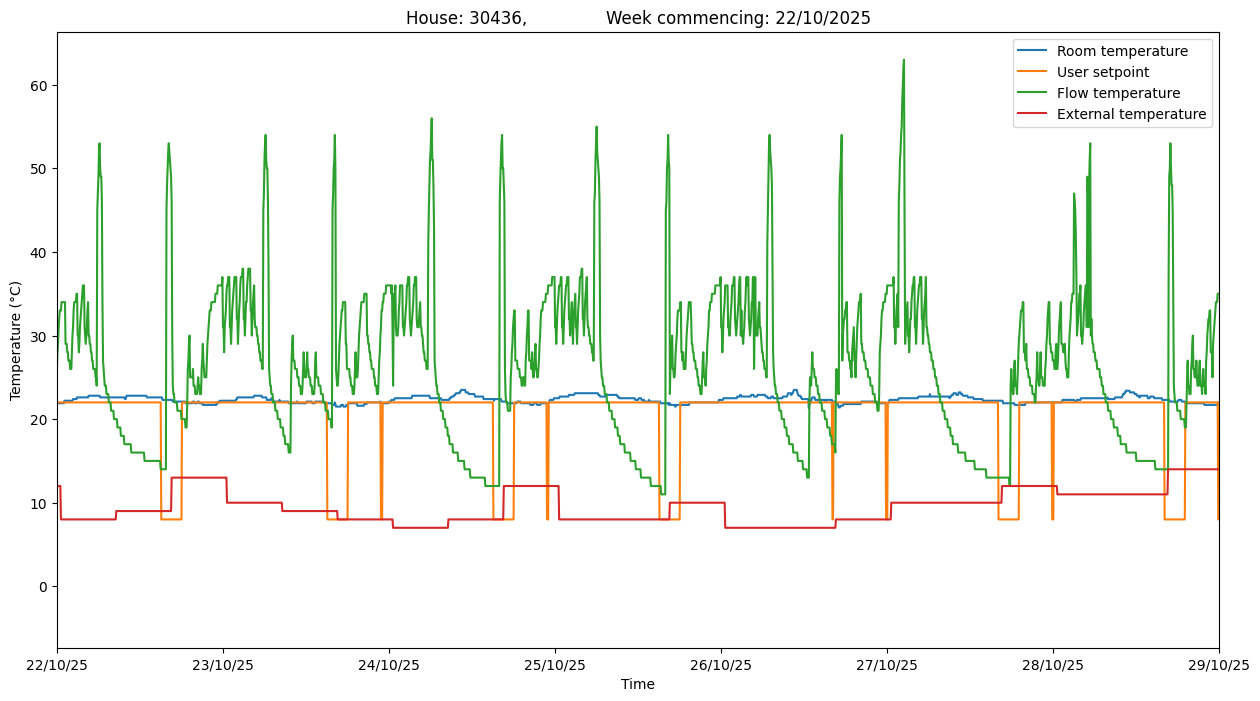

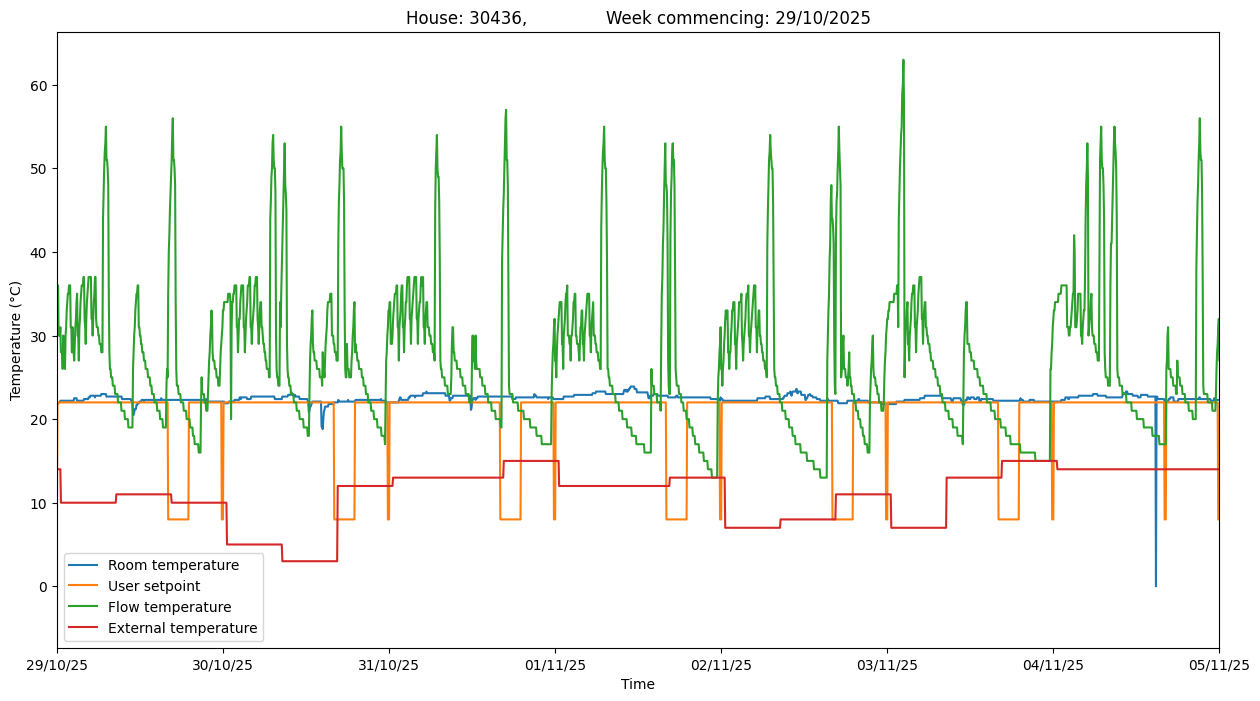

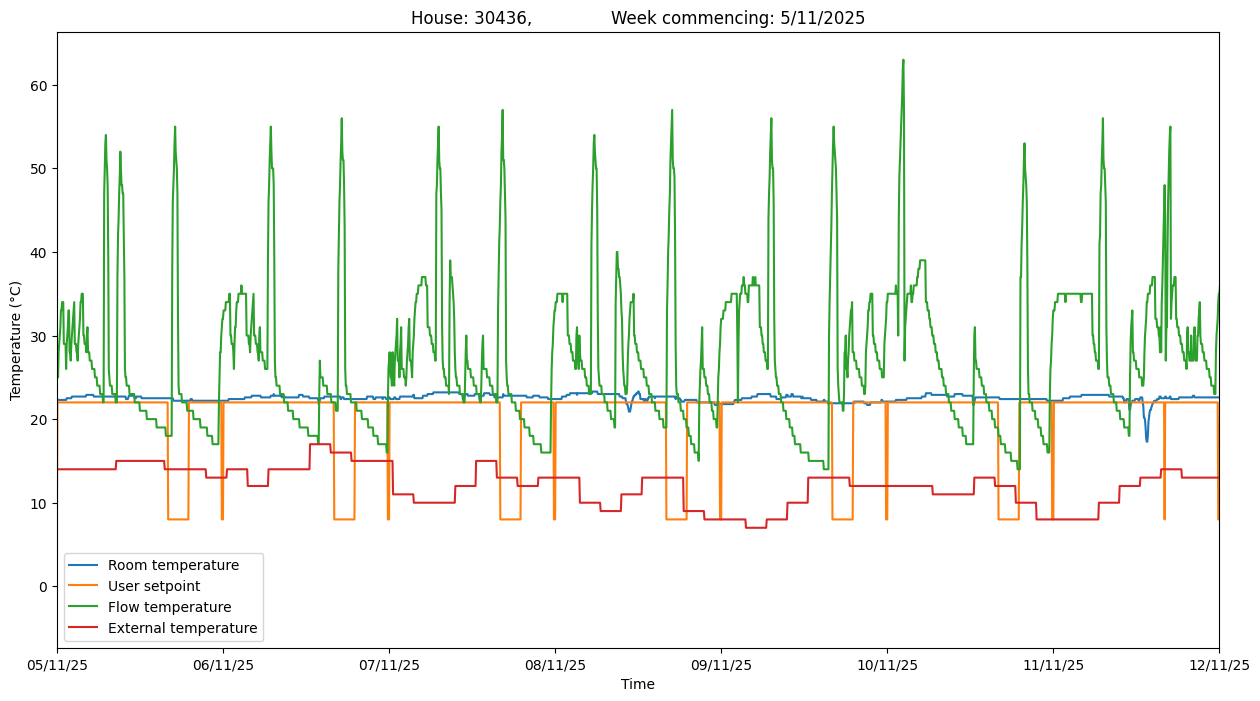

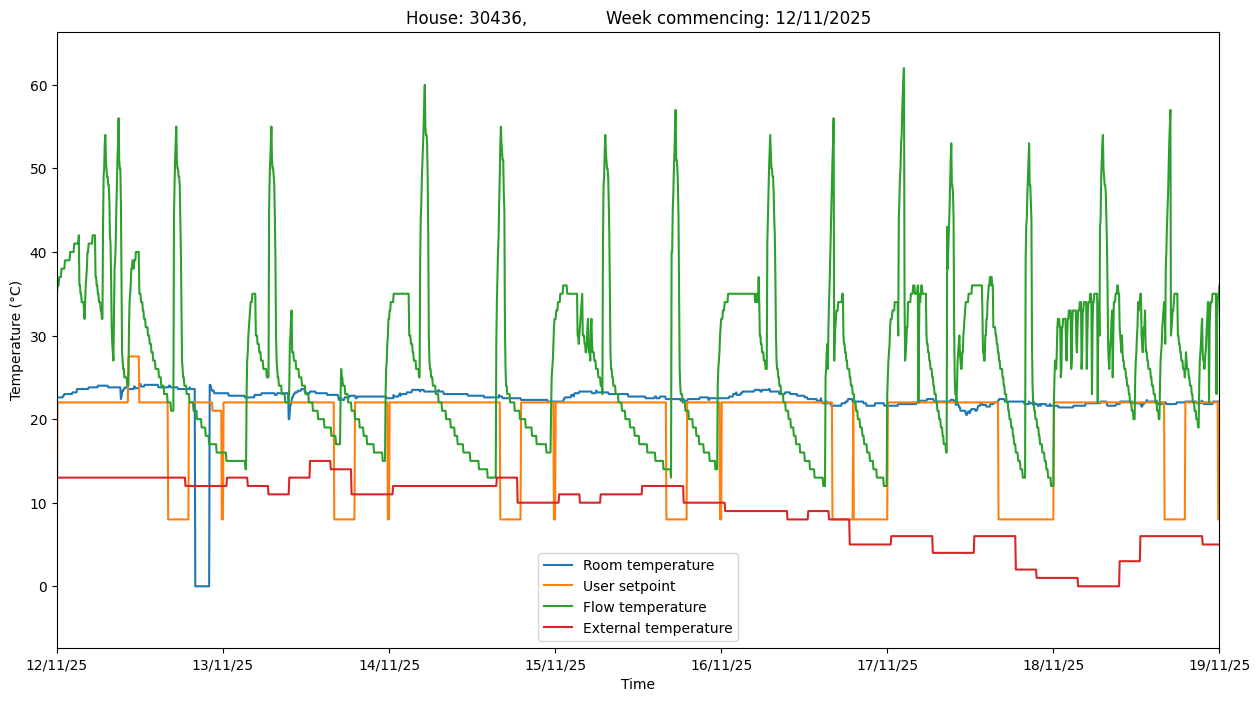

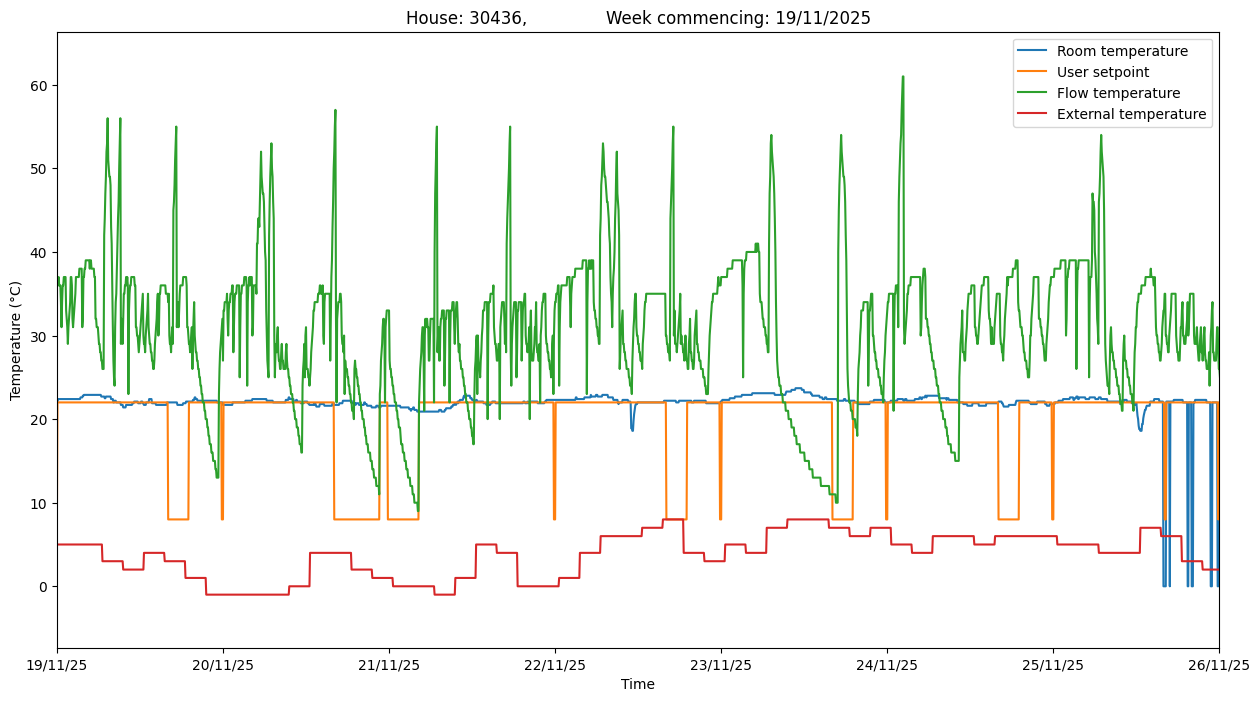

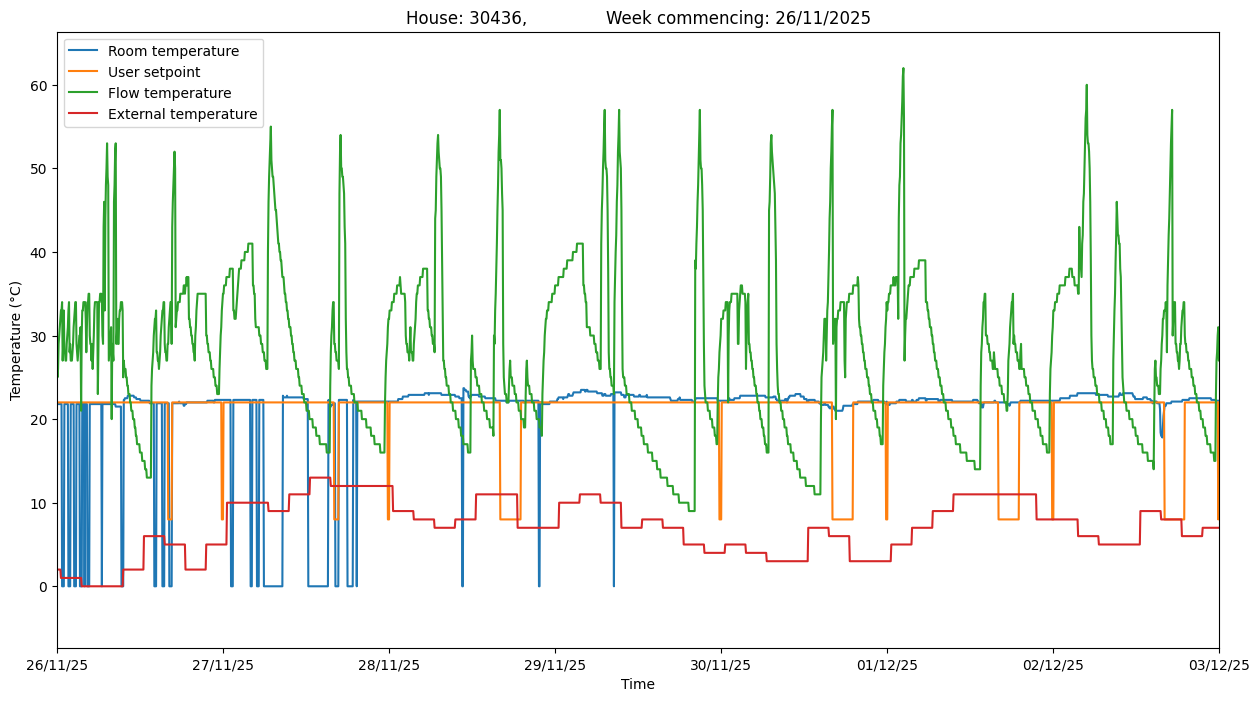

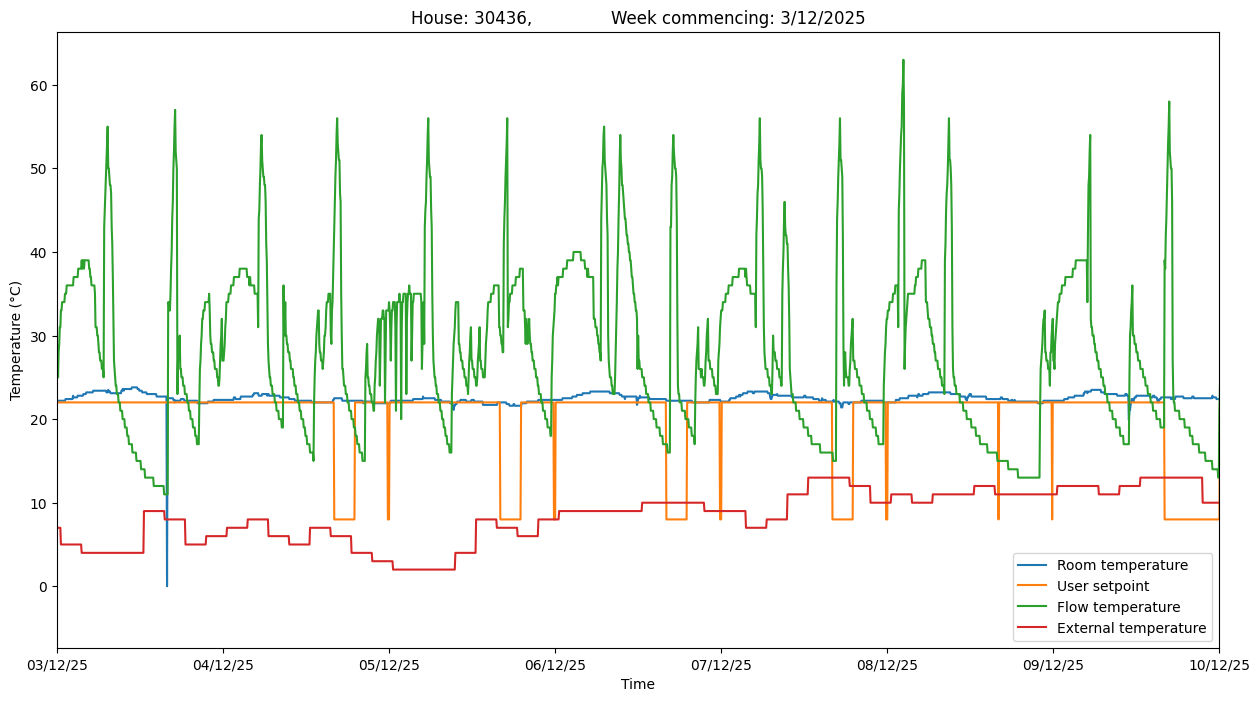

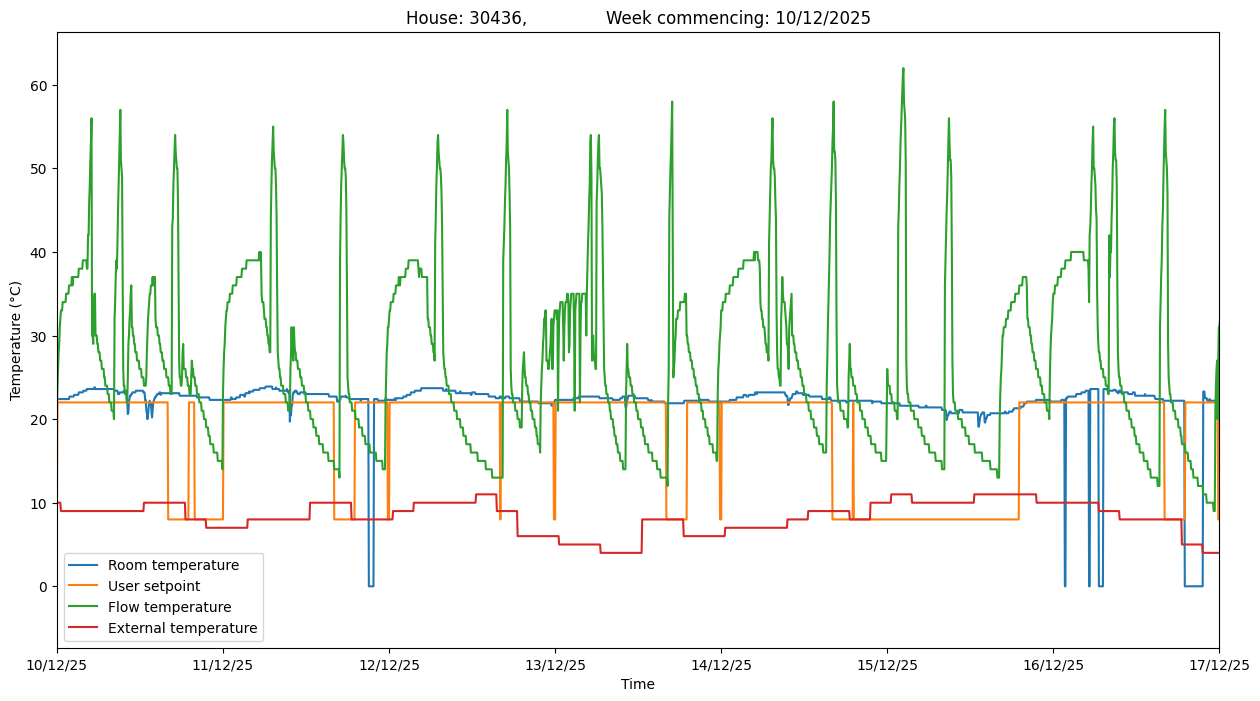

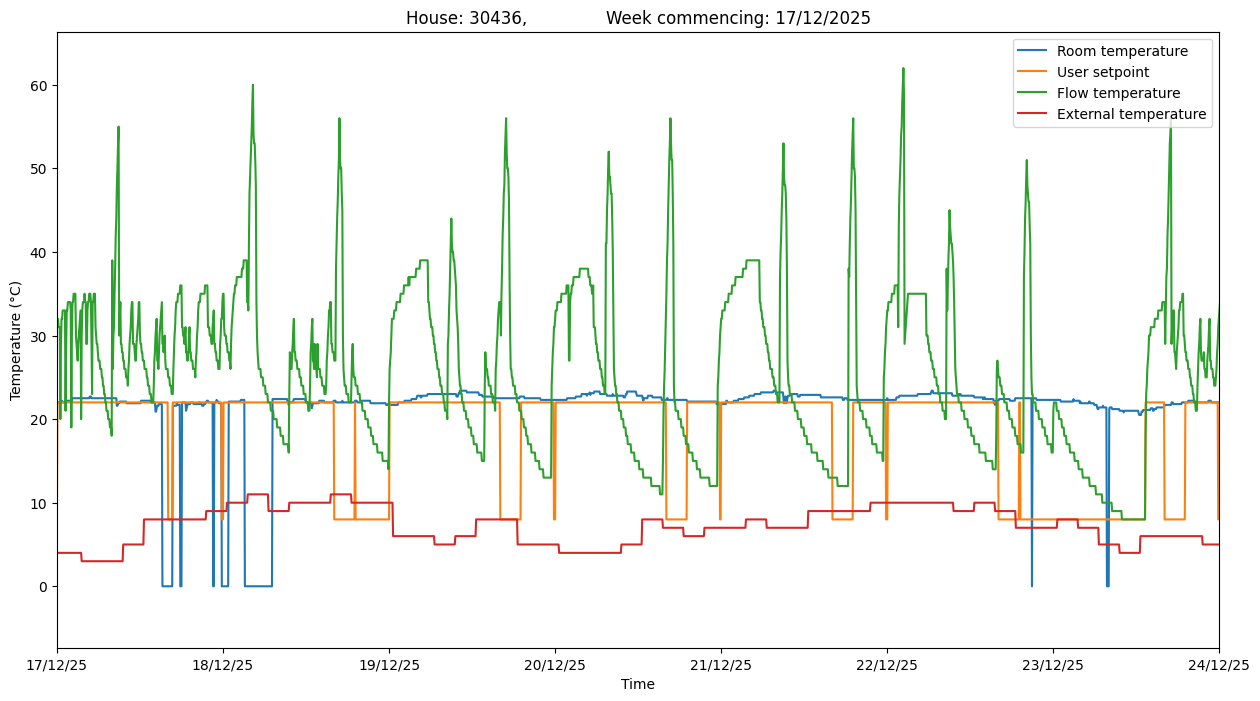

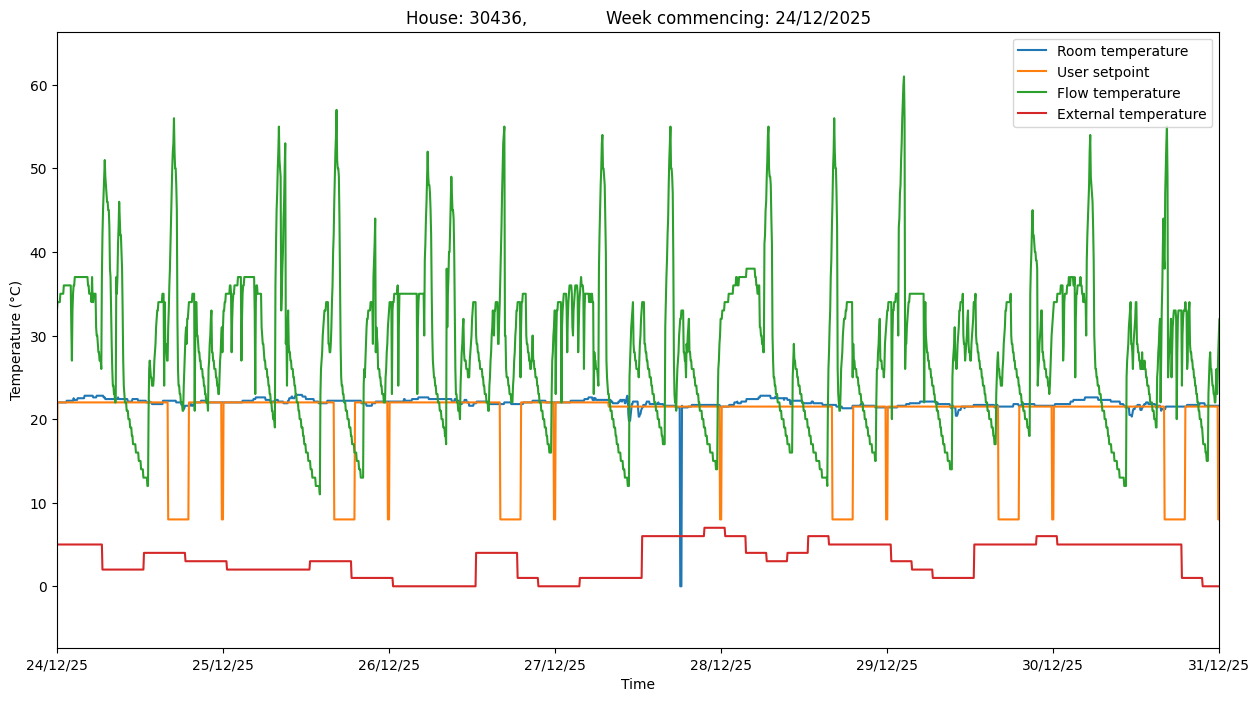

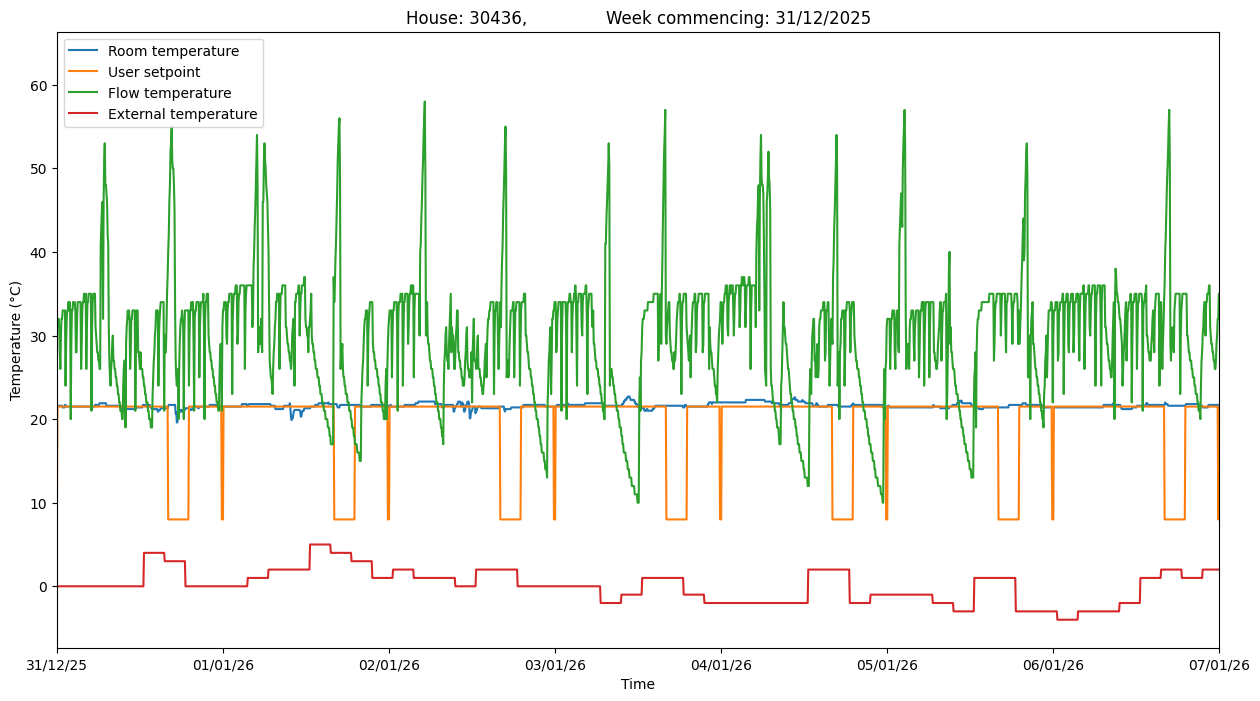

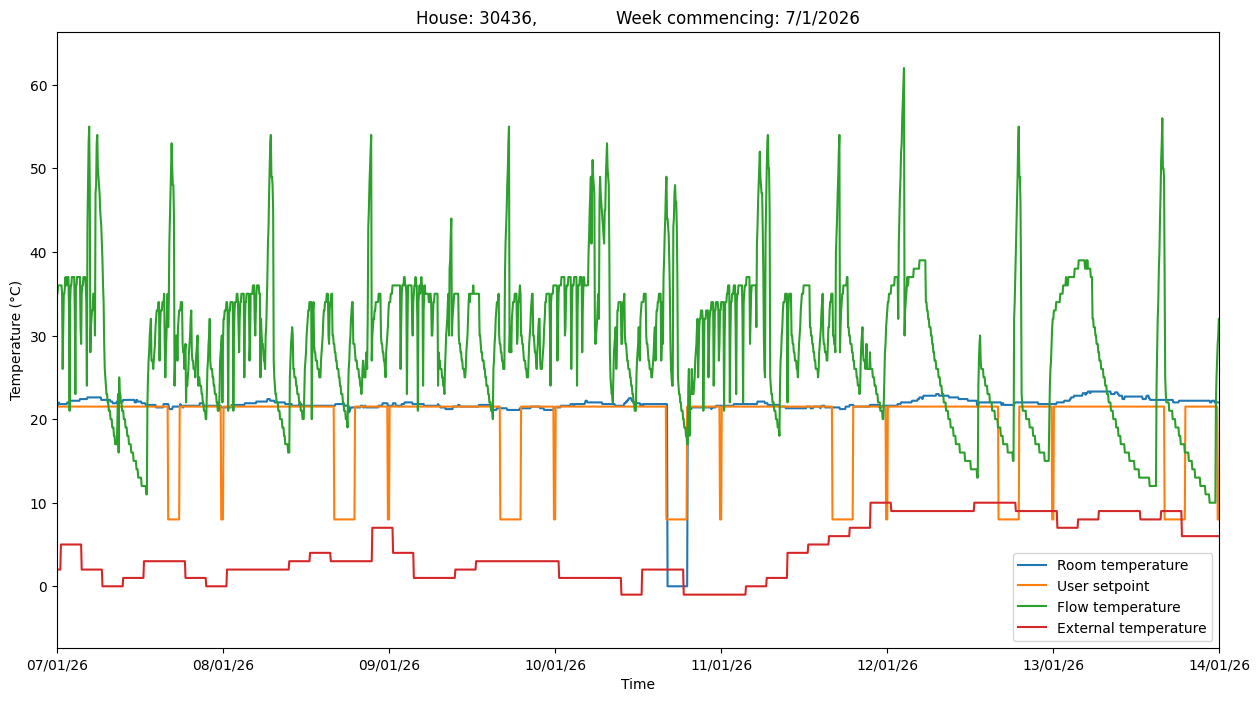

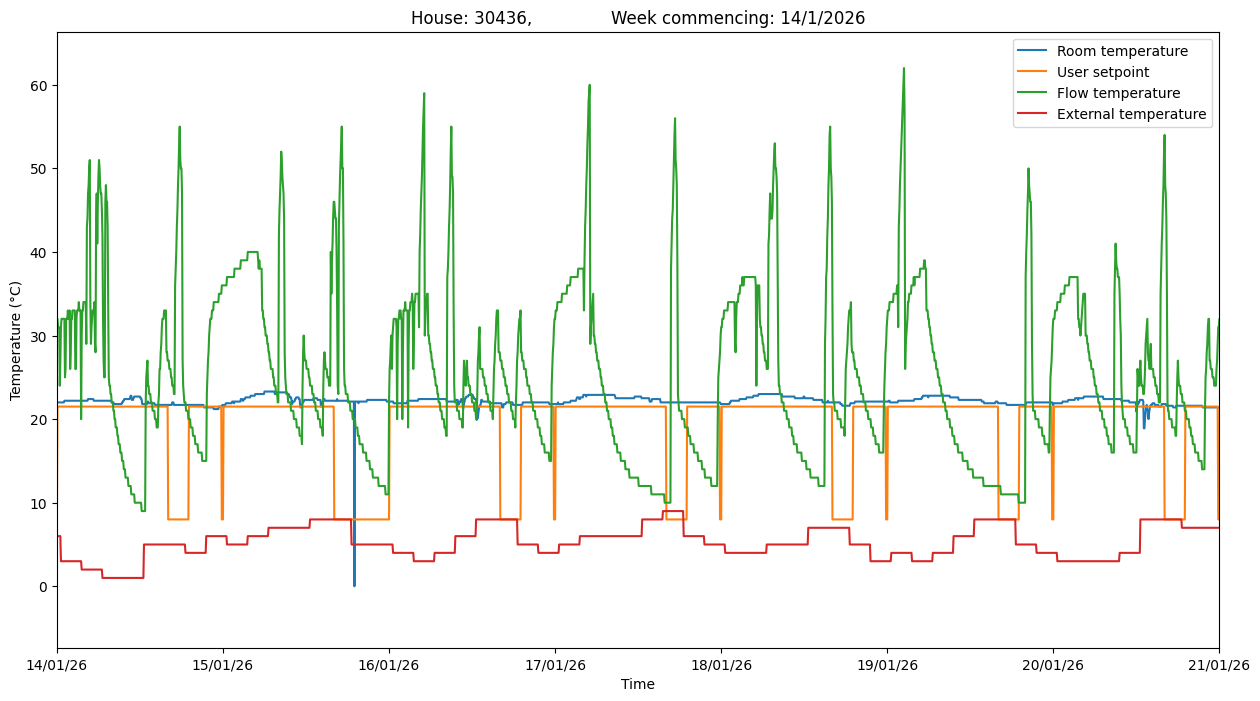

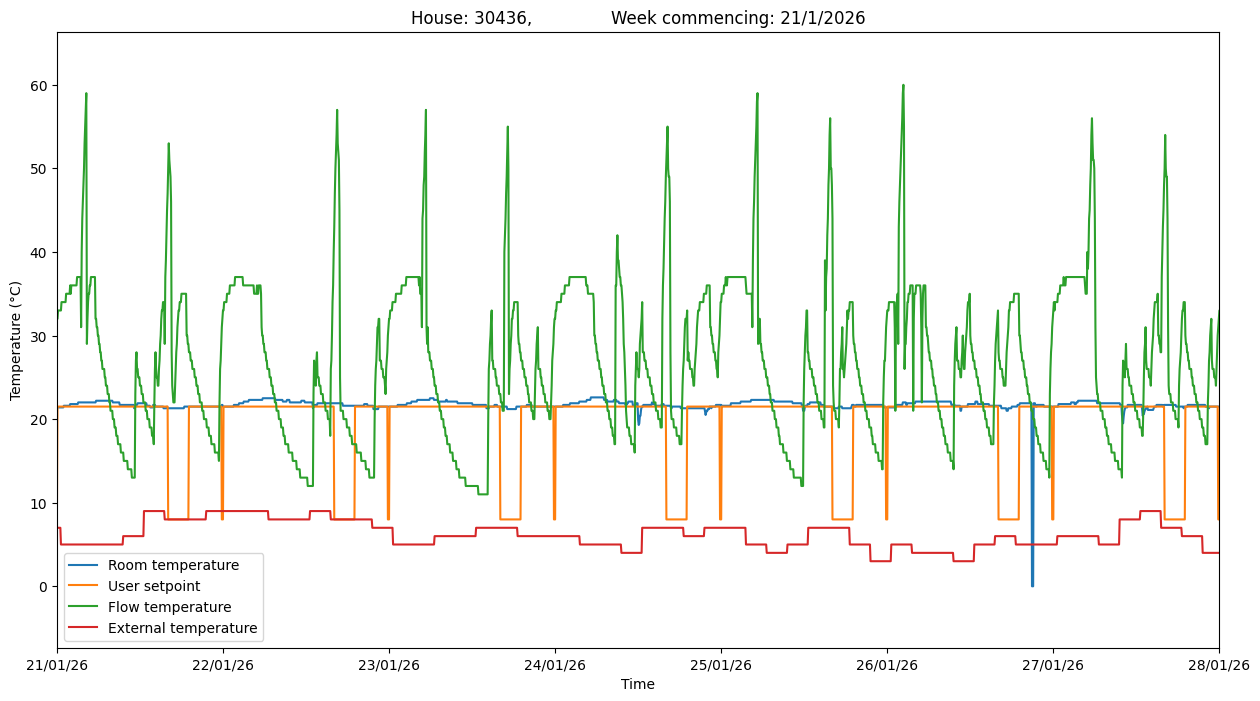

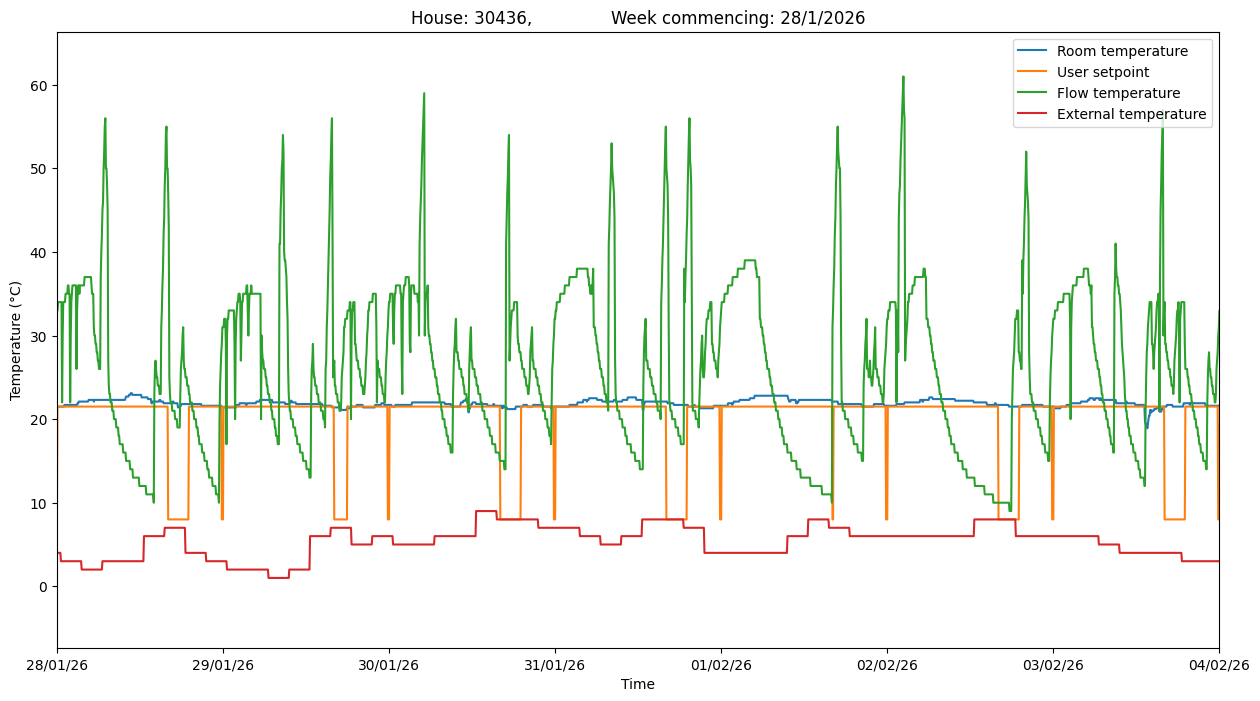

In [98]:
for i in range(num_weeks-1):
    # Plot temperature variation across training dataset
    fig = plt.figure(figsize=(15,8))
    plt.plot(house_df["Datetime"], house_df["Room temperature (Zone 1) (°C)"], label="Room temperature")
    plt.plot(house_df["Datetime"], house_df["Setpoint temperature (Zone 1) (°C)"], label="User setpoint")
    plt.plot(house_df["Datetime"], house_df["Flow temperature (°C)"], label="Flow temperature")
    plt.plot(house_df["Datetime"], house_df["External temperature (°C)"], label="External temperature")
    ax = plt.gca()
    ax.xaxis.set_major_locator(DayLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m/%y'))
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.xlim(house_df["Datetime"][i*datapoints_in_week], house_df["Datetime"][datapoints_in_week+i*datapoints_in_week])
    plt.title(f"House: {house_id}, \
              Week commencing: {house_df["Datetime"][i*(datapoints_in_week)].day}/{house_df["Datetime"][i*(datapoints_in_week)].month}/{house_df["Datetime"][i*(datapoints_in_week)].year}")
    plt.legend()
    plt.show()